In [1]:
import pandas as pd

csv_path = "D:\DATASETS\YFCC15M\yfcc15m.csv" 

print("Loading a sample of the YFCC15M dataset...")
df_sample = pd.read_csv(csv_path, nrows=500)
    
display(df_sample.head())

print("\nDataset Info (Sample):")
df_sample.info()

Loading a sample of the YFCC15M dataset...


,photoid,uid,unickname,datetaken,dateuploaded,capturedevice,title,description,usertags,machinetags,...,pageurl,downloadurl,licensename,licenseurl,serverid,farmid,secret,secretoriginal,ext,marker
0,29060,34427466731@N01,striatic,2004-05-02 17:12:01.0,1083543121,NaN,Christmas+Panorama+%7Bnotes%7D,a+link+to+a+much+higher+resolution+version%2C+...,"alberta,canada,christmas,edmonton,family,indoo...",NaN,...,http://www.flickr.com/photos/34427466731@N01/2...,http://farm1.staticflickr.com/1/29060_e90c2a0c...,Attribution License,http://creativecommons.org/licenses/by/2.0/,1,1,e90c2a0c1c,e90c2a0c1c,jpg,0
1,29205,34427469121@N01,George,2004-05-03 10:16:04.0,1083604564,NaN,La+Luna,From+outside+my+window.,"moon,vankie",NaN,...,http://www.flickr.com/photos/34427469121@N01/2...,http://farm1.staticflickr.com/1/29205_64d31038...,Attribution-NonCommercial-NoDerivs License,http://creativecommons.org/licenses/by-nc-nd/2.0/,1,1,64d31038b1,64d31038b1,jpg,0
2,29209,34427469121@N01,George,2004-05-03 10:16:06.0,1083604566,NaN,From+the+entry,This+is+what+you+see+-+with+no+furniture.,apartment,NaN,...,http://www.flickr.com/photos/34427469121@N01/2...,http://farm1.staticflickr.com/1/29209_6d55fad2...,Attribution-NonCommercial-NoDerivs License,http://creativecommons.org/licenses/by-nc-nd/2.0/,1,1,6d55fad203,6d55fad203,jpg,0
3,29294,37912375204@N01,Schlomo+Rabinowitz,2004-05-01 16:49:37.0,1083625746,SONY+DSC-V1,detail,detail+of+painting+by+Romanowski+and+friends,"abstract,graffiti,painting,romanowski,urban",NaN,...,http://www.flickr.com/photos/37912375204@N01/2...,http://farm1.staticflickr.com/1/29294_a0fc568d...,Attribution-NonCommercial-NoDerivs License,http://creativecommons.org/licenses/by-nc-nd/2.0/,1,1,a0fc568df3,a0fc568df3,jpg,0
4,29604,37912375204@N01,Schlomo+Rabinowitz,2004-04-23 15:51:18.0,1083731910,SONY+DSC-V1,meandwayne,on+his+rockstar+tourbus,"friend,me,mirror,notes,schlomo,unfound,wayne",NaN,...,http://www.flickr.com/photos/37912375204@N01/2...,http://farm1.staticflickr.com/1/29604_878d5a7d...,Attribution-NonCommercial-NoDerivs License,http://creativecommons.org/licenses/by-nc-nd/2.0/,1,1,878d5a7ddd,878d5a7ddd,jpg,0



Dataset Info (Sample):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   photoid         500 non-null    int64  
 1   uid             500 non-null    object 
 2   unickname       500 non-null    object 
 3   datetaken       500 non-null    object 
 4   dateuploaded    500 non-null    int64  
 5   capturedevice   307 non-null    object 
 6   title           500 non-null    object 
 7   description     500 non-null    object 
 8   usertags        480 non-null    object 
 9   machinetags     7 non-null      object 
 10  longitude       236 non-null    float64
 11  latitude        236 non-null    float64
 12  accuracy        236 non-null    float64
 13  pageurl         500 non-null    object 
 14  downloadurl     500 non-null    object 
 15  licensename     500 non-null    object 
 16  licenseurl      500 non-null    object 
 17  serverid   

In [3]:
import os

input_csv = "yfcc15m.csv"
output_csv = "yfcc15m_geotagged_only.csv"
new_csv_path = "D:\DATASETS\YFCC15M\yfcc15m_geotagged_only.csv"
chunk_size = 100000 

lat_col = 'latitude' 
lon_col = 'longitude'

print(f"Starting to filter {input_csv} in chunks. This might take a few minutes...")

first_chunk = True
total_saved = 0

for chunk in pd.read_csv(csv_path, chunksize=chunk_size, low_memory=False):
    
    filtered_chunk = chunk.dropna(subset=[lat_col, lon_col])
    filtered_chunk = filtered_chunk[(filtered_chunk[lat_col] != 0.0) | (filtered_chunk[lon_col] != 0.0)]
    
    if first_chunk:
        
        filtered_chunk.to_csv(output_csv, index=False, mode='w')
        first_chunk = False
    else:
        
        filtered_chunk.to_csv(output_csv, index=False, mode='a', header=False)
        
    total_saved += len(filtered_chunk)

print(f"Filtering complete! Saved {total_saved} valid geospatial rows to {output_csv}.")

Starting to filter yfcc15m.csv in chunks. This might take a few minutes...
Filtering complete! Saved 9490367 valid geospatial rows to yfcc15m_geotagged_only.csv.


Loading data sample for visualization...


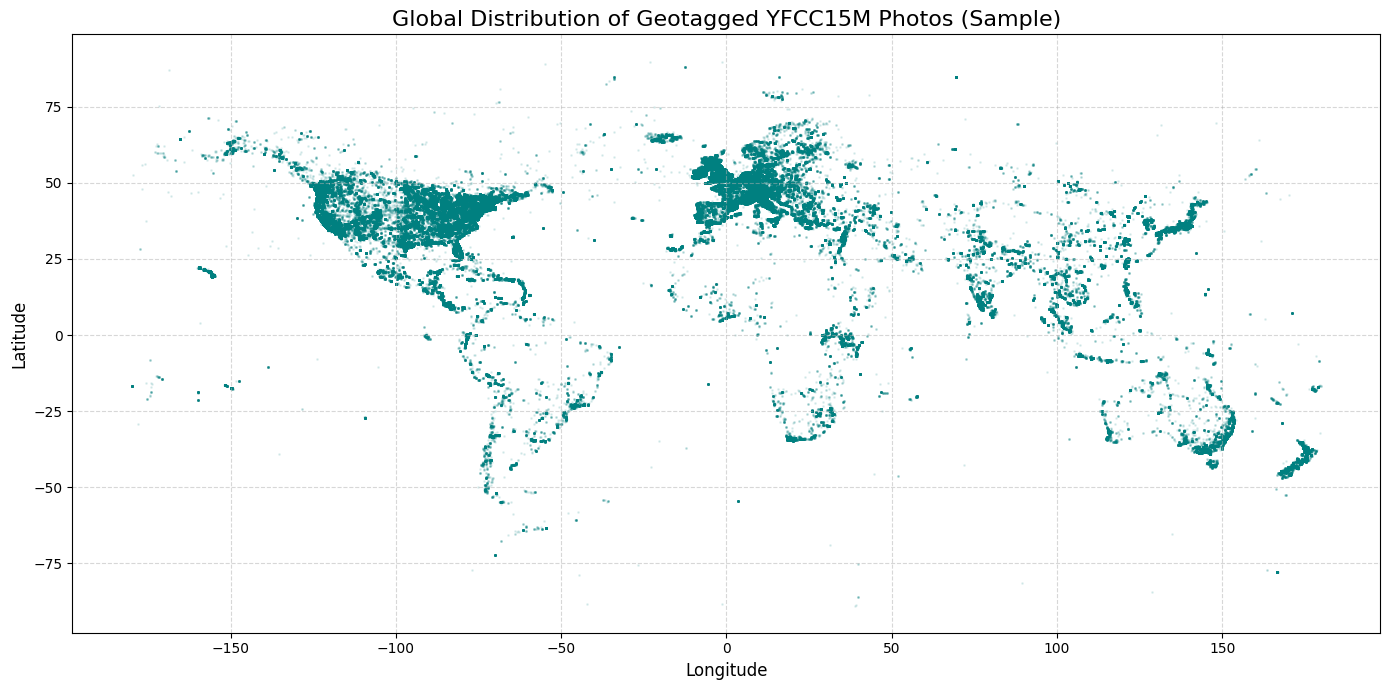

In [5]:
import matplotlib.pyplot as plt

clean_csv = "yfcc15m_geotagged_only.csv"

print("Loading data sample for visualization...")
df_vis = pd.read_csv(clean_csv, nrows=1000000)

lat_col = 'latitude'
lon_col = 'longitude'

plt.figure(figsize=(14, 7))

plt.scatter(df_vis[lon_col], df_vis[lat_col], s=1, alpha=0.1, c='teal')

plt.title('Global Distribution of Geotagged YFCC15M Photos (Sample)', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Could not load image at row 748. Error: 410 Client Error: Gone for url: https://farm1.staticflickr.com/1/236866_fd216807a1.jpg


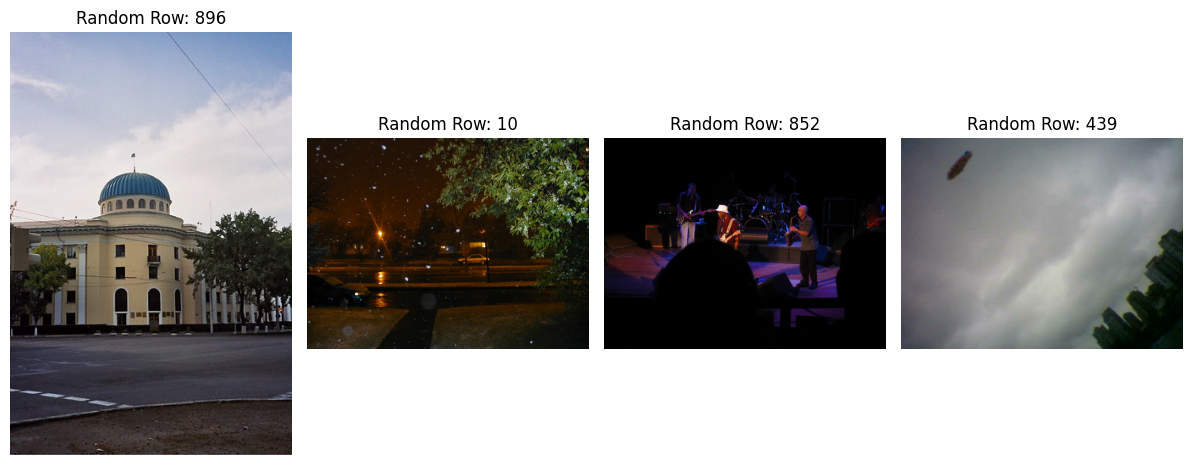

In [14]:
import requests
from PIL import Image
from io import BytesIO

pool_size = 1000

df_pool = pd.read_csv(clean_csv, nrows=pool_size)

df_images = df_pool.sample(n=5, random_state=None) 

url_col = 'downloadurl' 

plt.figure(figsize=(15, 5))

for i, (idx, row) in enumerate(df_images.iterrows()):
    img_url = row[url_col]
    
    try:
        headers = {'User-Agent': 'Mozilla/5.0'}
        response = requests.get(img_url, headers=headers, timeout=5)
        response.raise_for_status() 
        
        img = Image.open(BytesIO(response.content))
        
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Random Row: {idx}")
        
    except Exception as e:
        print(f"Could not load image at row {idx}. Error: {e}")

plt.tight_layout()
plt.show()

In [15]:
target_csv = "yfcc15m_geotagged_only.csv"
temp_csv = "temp_yfcc.csv"

time_col = 'datetaken' 

chunk_size = 100000
first_chunk = True
total_saved = 0

for chunk in pd.read_csv(target_csv, chunksize=chunk_size, low_memory=False):
    
    filtered_chunk = chunk.dropna(subset=[time_col])
    
    if first_chunk:
        filtered_chunk.to_csv(temp_csv, index=False, mode='w')
        first_chunk = False
    else:
        filtered_chunk.to_csv(temp_csv, index=False, mode='a', header=False)
        
    total_saved += len(filtered_chunk)

try:
    os.replace(temp_csv, target_csv)
    print(f"Update complete! {target_csv} has been overwritten with {total_saved} cleaned rows.")
except Exception as e:
    print(f"Error swapping files: {e}. The cleaned data is safe in {temp_csv}.")

Update complete! yfcc15m_geotagged_only.csv has been overwritten with 9490212 cleaned rows.
